# **Análisis de sentimiento**

En este notebook utilizamos tres modelos distintos para hacer un análisis de sentimiento. No esperamos resultados concluyentes porque al ser texto con lenguaje legal suele tener sentimiento neutro.

Para que no sea muy costoso utilizaremos un subconjunto de 5mil muestras de los datos.

In [1]:
import pandas as pd

df = pd.read_csv("dataset_universidades_procesado.csv")

# Muestra de 5000 datos para analizar modelos
df_sample = df.sample(5_000, random_state=42)

df_sample.head()


,ID_Disposicion,Fecha_Publicacion,Titulo_Semantico,Año_Semana,Año,Bloque_3dias,texto_limpio,texto_lower,Mes,Trimestre,Bloques_dias_semana,Dia_semana_num,Dia_semana,longitud_titulo
116535,BOE-B-2016-2684,2016-01-29,Anuncio de formalización de contratos de: Rect...,2016-04,2016,2199,Anuncio de formalizacion de contratos de Recto...,anuncio de formalizacion de contratos de recto...,1,2016Q1,2199,4,Friday,87
94335,BOE-A-2011-9376,2011-05-30,"Resolución de 26 de abril de 2011, de la Unive...",2011-22,2011,1712,Resolucion de de abril de de la Universidad Po...,resolucion de de abril de de la universidad po...,5,2011Q2,1712,0,Monday,41
53746,BOE-A-2003-16803,2003-08-27,"Resolución de 31 de julio de 2003, conjunta de...",2003-35,2003,902,Resolucion de de julio de conjunta de la Unive...,resolucion de de julio de conjunta de la unive...,8,2003Q3,902,2,Wednesday,62
128349,BOE-A-2018-1708,2018-02-08,"Resolución de 30 de enero de 2018, de la Unive...",2018-06,2018,2411,Resolucion de de enero de de la Universidad Na...,resolucion de de enero de de la universidad na...,2,2018Q1,2410,3,Thursday,29
132095,BOE-B-2018-40549,2018-08-11,Anuncio de la Facultad de Filología de la Univ...,2018-32,2018,2463,Anuncio de la Facultad de Filologia de la Univ...,anuncio de la facultad de filologia de la univ...,8,2018Q3,2463,5,Saturday,16


Usamos tres modelos con distinto enfoque:
- VADER (de nltk), rápido
- cardiffnlp/twitter-xlm-roberta-base-sentiment, multilingüe y bueno para textos cortos
- pysentimiento/robertuito-sentiment-analysis que está entrenado en español.

## 1. VADER

In [2]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

vader = SentimentIntensityAnalyzer()
df_sample['sent_vader'] = df_sample['texto_lower'].apply(lambda x: vader.polarity_scores(x)['compound'])


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


## 2. XLM-Roberta: Multilingüe

In [3]:
from transformers import pipeline

modelo_roberta = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment")
df_sample['sent_roberta'] = df_sample['texto_lower'].apply(lambda x: modelo_roberta(x[:512])[0]['label'])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


## 3. Robertuito: Español

In [4]:
modelo_robertuito = pipeline("sentiment-analysis", model="pysentimiento/robertuito-sentiment-analysis")
df_sample['sent_robertuito'] = df_sample['texto_lower'].apply(lambda x: modelo_robertuito(x[:512])[0]['label'])

config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Device set to use cuda:0


## Comparación de resultados por modelo

**VADER**

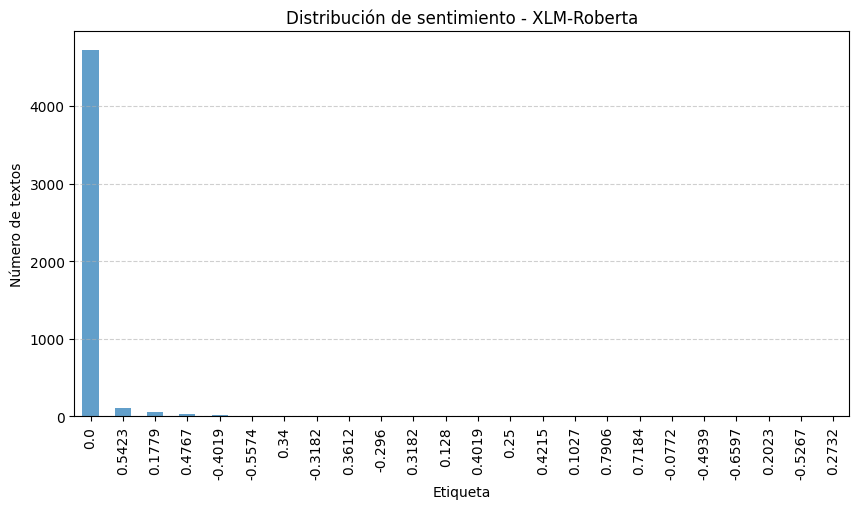

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df_sample['sent_vader'].value_counts().plot(kind='bar', alpha=0.7)
plt.title('Distribución de sentimiento - XLM-Roberta')
plt.xlabel('Etiqueta')
plt.ylabel('Número de textos')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Roberta**

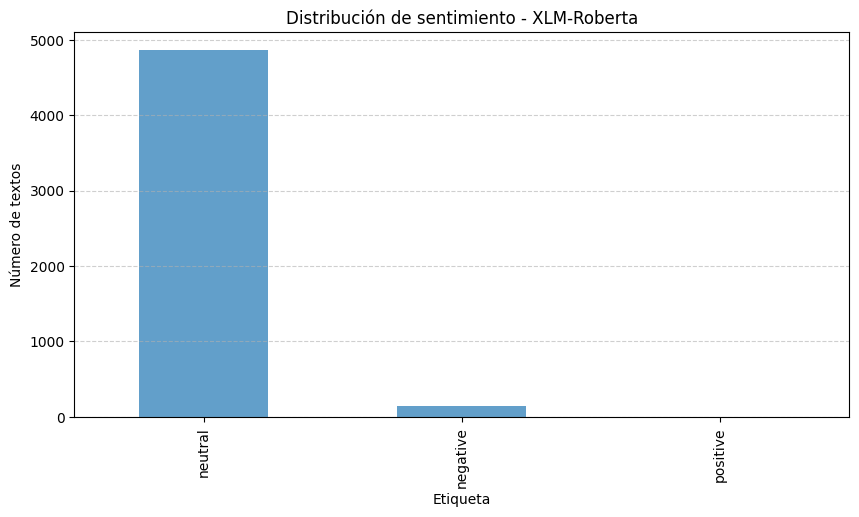

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df_sample['sent_roberta'].value_counts().plot(kind='bar', alpha=0.7)
plt.title('Distribución de sentimiento - XLM-Roberta')
plt.xlabel('Etiqueta')
plt.ylabel('Número de textos')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Robertuito**

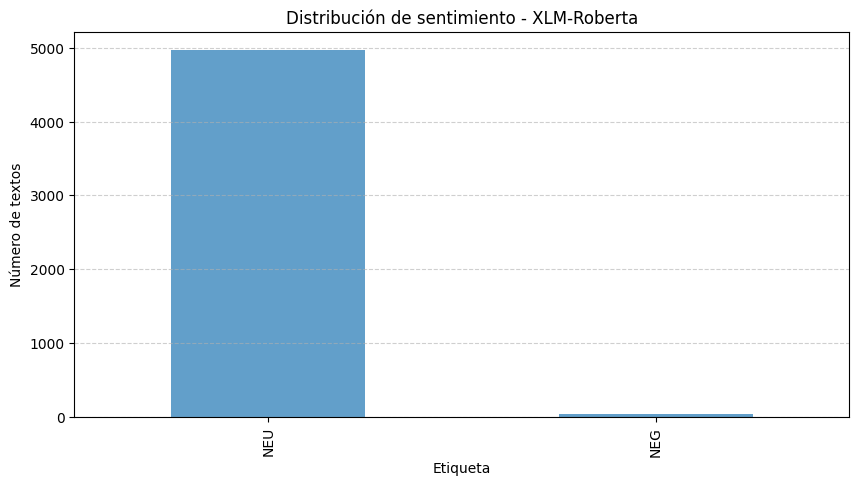

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df_sample['sent_robertuito'].value_counts().plot(kind='bar', alpha=0.7)
plt.title('Distribución de sentimiento - XLM-Roberta')
plt.xlabel('Etiqueta')
plt.ylabel('Número de textos')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Como podemos ver en las gráficas todos los modelos detectan sentimiento neutro en la muestra del dataset, por lo que el análisis de sentimiento en nuestro caso no va a ser definitivo.